### Esercitazione clustering incrementale - k-means

In [15]:
import random
from influxdb_client import InfluxDBClient, BucketsApi, BucketRetentionRules, Point, WritePrecision
from datetime import datetime, timedelta, timezone
import influxdb_client
import psutil
import numpy as np
import random, time
import pandas as pd
from sklearn.cluster import KMeans
from river import cluster
import matplotlib.pyplot as plt

# Setup e connessione al server InfluxDB
org_name = "spamic"
token = "6ANpdrZyP8Nk7HBib5puP7dx8fJrFNG2xCPlBiXqDSKAsSfjKsUMPlgEVvoQMllyP0HCDAlherDBZZA_z42utw=="
url = "http://localhost:8086"
bucket_name = "iot_cluster_data"
client = influxdb_client.InfluxDBClient(url=url, token=token, org=org_name)
write_api = client.write_api()

In [1]:
# Funzione per inseire dati generati casualmente su InfluxDB
def insert_sensor_data(client, n_values):
    interval = timedelta(seconds=1)

    start_time = datetime.now(timezone.utc)

    for i in range(n_values):
        timestamp = start_time + i * interval

        temperature = round(random.uniform(15.0, 30.0), 2)
        humidity = round(random.uniform(30.0, 70.0), 2)

        # Costruisco dati sensore
        data = [
            {
                "measurement": "sensor_data",
                "time" : timestamp.strftime('%Y-%m-%dT%H:%M:%SZ'),
                "fields": {
                    "temperature": temperature,
                    "humidity": humidity
                }
            }
        ]

        client.write_api().write(bucket=bucket_name, org=org_name, record=data)
        time.sleep(1)

In [5]:
number_of_values = 100
time_interval = []

current_time = datetime.now(timezone.utc).strftime('%Y-%m-%dT%H:%M:%SZ')
time_interval.append(current_time)
time.sleep(10)

for i in range(3):
    insert_sensor_data(client, number_of_values)
    current_time = datetime.now(timezone.utc).strftime('%Y-%m-%dT%H:%M:%SZ')
    time_interval.append(current_time)

    print(f"Inserted {number_of_values} values at {current_time}")
    time.sleep(10)

client.close()

Inserted 100 values at 2026-03-12T20:59:15Z
Inserted 100 values at 2026-03-12T21:01:05Z
Inserted 100 values at 2026-03-12T21:02:57Z


In [16]:
def query_sensor_data(client, bucket_name, start_time, end_time):
    """
    Recupera i dati dei sensori dal bucket INFLUXDB per un intervallo di tempo specificato.

    Parametri:
    - client: istanza del client InfluxDB
    - bucket_name: nome del bucket da cui recuperare i dati
    - start_time: timestamp di inizio dell'intervallo (formato ISO)
    - end_time: timestamp di fine dell'intervallo (formato ISO)

    Ritorna:
    - DataFrame contenente i dati dei sensori recuperati
    """
    query = f'''
    from(bucket: "{bucket_name}")
      |> range(start: {start_time}, stop: {end_time})
      |> filter(fn: (r) => r._measurement == "sensor_data")
    '''
    
    try:
        result = client.query_api().query(query)
        data = []
        for table in result:
            for record in table.records:
                data.append((record.get_time(), record.get_field(), record.get_value()))
        return pd.DataFrame(data, columns=["time", "field", "value"])
    except Exception as e:
        print(f"Error executing query: {e}")
        return pd.DataFrame()  # Ritorna un DataFrame vuoto in caso di errore

In [19]:
def perform_clustering_and_visualization(sensor_data, start_time, end_time):
    # Filtra i dati per temperature e umidità
    temperature = sensor_data[sensor_data['field'] == 'temperature']
    humidity = sensor_data[sensor_data['field'] == 'humidity']

    #Combina i dati in un unico DataFrame
    combined_data = pd.DataFrame({
        "temperature": temperature['value'].values,
        "humidity": humidity['value'].values
    })

    n_clusters = 3
    kmeans = KMeans(n_clusters=n_clusters)
    combined_data['cluster'] = kmeans.fit_predict(combined_data)

    plt.figure(figsize=(10,6))
    colors = ['red', 'green', 'blue']
    markers = ['o', 's', 'D']

    for i in range(n_clusters):
        cluster_data = combined_data[combined_data['cluster'] == i]
        plt.scatter(cluster_data['temperature'], cluster_data['humidity'], 
                    color=colors[i % len(colors)], marker=markers[i % len(markers)], label=f'Cluster {i}', edgecolors='k', s=100)
    
    # Traccia i centri del cluster
    centers = kmeans.cluster_centers_
    plt.scatter(centers[:, 0], centers[:, 1], color='black', marker='X', label='Centroide', edgecolors='k', s=200)

    # Migliorare visualizzazione
    plt.title(f'Clustering dei dati dei sensori\nIntervallo: {start_time} - {end_time}', fontsize=14)
    plt.xlabel('Temperatura (°C)', fontsize=12)
    plt.ylabel('Umidità (%)', fontsize=12)
    plt.xlim(combined_data['temperature'].min() - 5, combined_data['temperature'].max() + 5)
    plt.ylim(combined_data['humidity'].min() - 5, combined_data['humidity'].max() + 5)
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

Querying data from 2026-03-12T20:57:24Z to 2026-03-12T20:59:15Z...


c:\Users\Spazzo\anaconda3\envs\sistemi-evolutivi-big-data\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


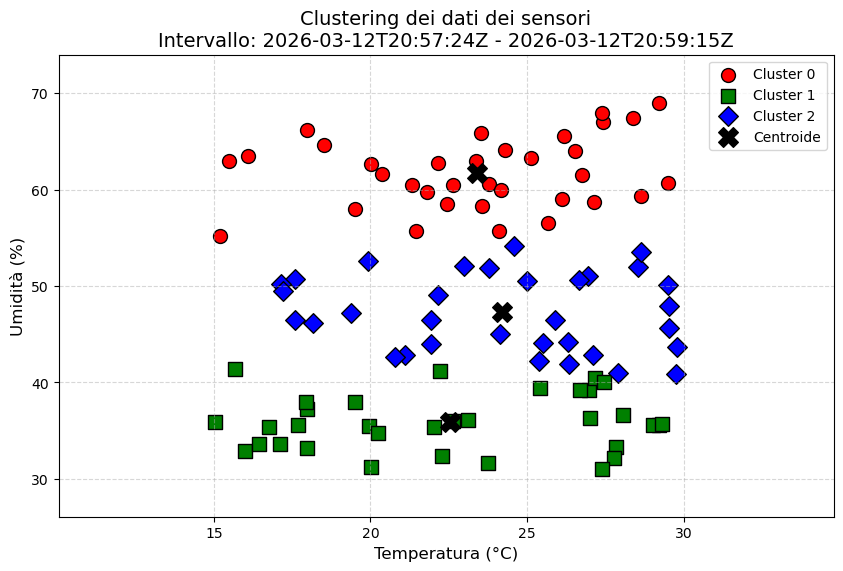

Querying data from 2026-03-12T20:59:15Z to 2026-03-12T21:01:05Z...


c:\Users\Spazzo\anaconda3\envs\sistemi-evolutivi-big-data\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


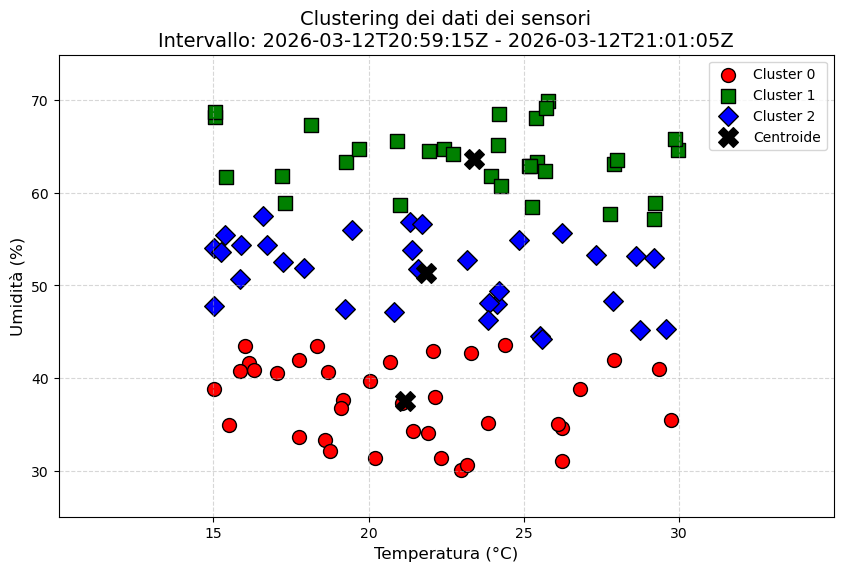

Querying data from 2026-03-12T21:01:05Z to 2026-03-12T21:02:57Z...


c:\Users\Spazzo\anaconda3\envs\sistemi-evolutivi-big-data\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


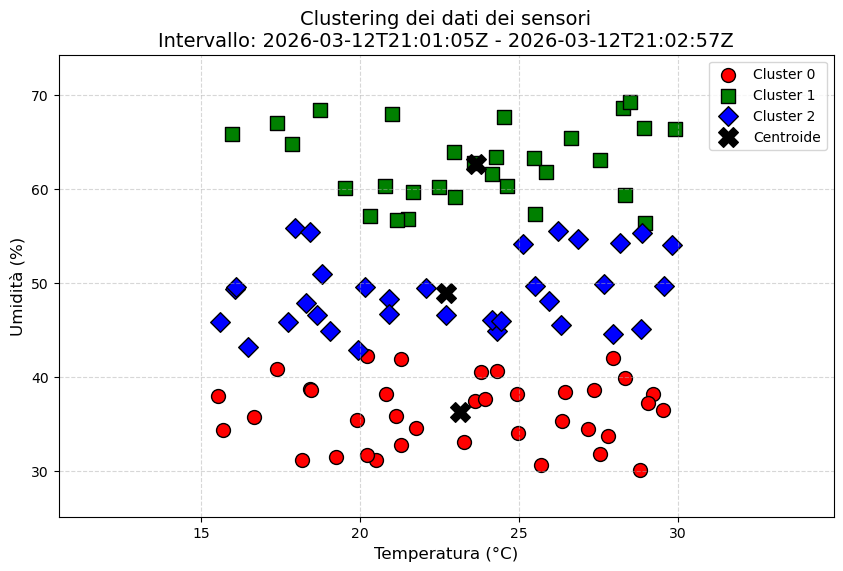

In [20]:
#Estrazione dei dati a blocchi ed esecuzione clustering
for i in range(len(time_interval)-1):
    start_time = time_interval[i]
    end_time = time_interval[i+1]

    print(f"Querying data from {start_time} to {end_time}...")
    sensor_data = query_sensor_data(client, bucket_name, start_time, end_time)

    perform_clustering_and_visualization(sensor_data, start_time, end_time)